In [1]:
!pip install torchsummary -q

# 🐾 Pet Insight 360 — Emotion Model Training

Transfer Learning with **MobileNetV2** for Pet Emotion Classification (4 classes)

| Component | Detail |
|---|---|
| Model | MobileNetV2 (ImageNet pretrained) |
| Classes | Angry, Happy, Other, Sad |
| Input Size | 224×224 RGB |
| Output | `pet_emotion.pth` for backend |

In [2]:
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm kagglehub mlflow -q

In [3]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# MLflow
import mlflow
import mlflow.pytorch
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from mlflow_tracking import PetMLflow

print(f'PyTorch version: {torch.__version__}')
print(f'MLflow version: {mlflow.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0
MLflow version: 3.10.0
CUDA available: False


## 📅 Download Dataset & Configuration

In [4]:
import kagglehub

# Download latest version
DATA_DIR = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")
print("Path to dataset files:", DATA_DIR)

# Show contents
for item in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, item)
    if os.path.isdir(full):
        count = len([f for f in os.listdir(full) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  📁 {item}/ — {count} images")

Path to dataset files: /Users/iam.pxk/.cache/kagglehub/datasets/anshtanwar/pets-facial-expression-dataset/versions/11
  📁 Angry/ — 250 images
  📁 Master Folder/ — 0 images
  📁 Other/ — 250 images
  📁 Sad/ — 250 images
  📁 happy/ — 250 images


In [5]:
# ============================================================
# Configuration
# ============================================================
EMOTION_LABELS = ["angry", "happy", "other", "sad"]
NUM_CLASSES = len(EMOTION_LABELS)
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # macOS multiprocessing issue — use 0

print(f"Device: {DEVICE}")
print(f"Classes: {EMOTION_LABELS}")
print(f"Batch size: {BATCH_SIZE} | Epochs: {EPOCHS} | Workers: {NUM_WORKERS}")

Device: cpu
Classes: ['angry', 'happy', 'other', 'sad']
Batch size: 32 | Epochs: 30 | Workers: 0


In [6]:
# ============================================================
# MLflow — Start Training Run
# ============================================================
tracker = PetMLflow()
run = tracker.start_training_run(
    run_name="mobilenetv2-emotion-v1",
    params={
        "model": "MobileNetV2",
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "optimizer": "Adam",
        "weight_decay": 5e-3,
        "dropout": "0.4+0.2",
        "scheduler": "ReduceLROnPlateau",
        "frozen_layers": 100,
        "dataset": "anshtanwar/pets-facial-expression-dataset",
    }
)
print(f"MLflow Run ID: {run.info.run_id}")

[MLflow] Tracking URI: sqlite:////Users/iam.pxk/Desktop/CNN_Meow/backend/mlruns.db
[MLflow] Training run started: 6f5179b88afa41c78719360f02019268
MLflow Run ID: 6f5179b88afa41c78719360f02019268


## 📂 Load Dataset

In [7]:
class PetEmotionDataset(Dataset):
    def __init__(self, root_dir, emotion_labels, transform=None):
        self.samples = []
        self.transform = transform
        
        # Case-insensitive folder matching
        all_folders = {f.lower(): f for f in os.listdir(root_dir)
                       if os.path.isdir(os.path.join(root_dir, f))}
        
        for idx, label in enumerate(emotion_labels):
            folder_name = all_folders.get(label.lower())
            if folder_name is None:
                print(f"  ⚠️ [{idx}] '{label}' — NOT FOUND")
                continue
            folder_path = os.path.join(root_dir, folder_name)
            count = 0
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(folder_path, fname), idx))
                    count += 1
            print(f"  ✅ [{idx}] {label:>8s} → '{folder_name}/' — {count} images")
        
        print(f"  📊 Total: {len(self.samples)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

print("Loading dataset...")
full_dataset = PetEmotionDataset(DATA_DIR, EMOTION_LABELS)
assert len(full_dataset) > 0, "Dataset is empty! Check DATA_DIR."

Loading dataset...
  ✅ [0]    angry → 'Angry/' — 250 images
  ✅ [1]    happy → 'happy/' — 250 images
  ✅ [2]    other → 'Other/' — 250 images
  ✅ [3]      sad → 'Sad/' — 250 images
  📊 Total: 1000 images


## 🔄 Data Augmentation & DataLoaders

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Split 80/20
n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        path, label = self.dataset.samples[self.indices[idx]]
        try:
            img = Image.open(path).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = SubsetWithTransform(full_dataset, train_indices, train_transform)
val_ds = SubsetWithTransform(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✅ Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"✅ Batches: {len(train_loader)} train / {len(val_loader)} val")


✅ Train: 800 | Val: 200
✅ Batches: 25 train / 7 val


## 🔍 Visualize Samples

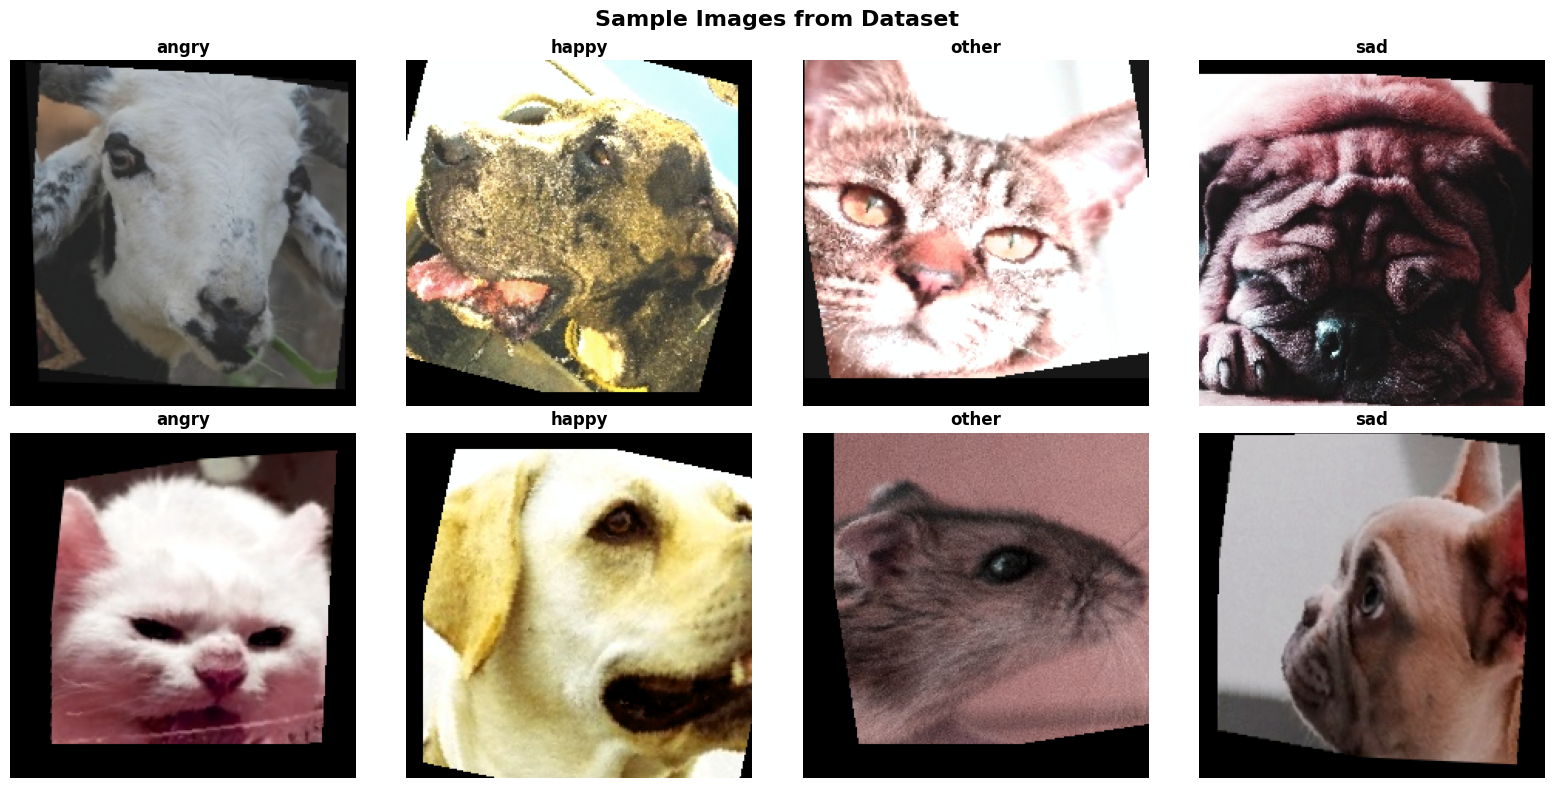

In [9]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4*NUM_CLASSES, 8))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
shown = {i: 0 for i in range(NUM_CLASSES)}
for img, label in train_ds:
    if shown[label] < 2:
        row, col = shown[label], label
        img_np = np.clip(std * img.permute(1,2,0).numpy() + mean, 0, 1)
        axes[row, col].imshow(img_np)
        axes[row, col].set_title(EMOTION_LABELS[label], fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
        shown[label] += 1
    if all(v >= 2 for v in shown.values()): break
plt.tight_layout()
plt.show()

## 🧠 Model Definition — MobileNetV2 Transfer Learning

In [10]:
class PetEmotionNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        in_features = backbone.last_channel
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
        for i, param in enumerate(self.features.parameters()):
            if i < 100:
                param.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = PetEmotionNet(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PetEmotionNet | Total: {total_params:,} | Trainable: {trainable:,} | Device: {DEVICE}")

PetEmotionNet | Total: 2,552,836 | Trainable: 2,191,556 | Device: cpu


In [11]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

## 🏋️ Training

In [12]:
# Class weights
class_counts = [0] * NUM_CLASSES
for _, label in full_dataset.samples:
    class_counts[label] += 1
total_samples = sum(class_counts)
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * c) if c > 0 else 1.0 for c in class_counts],
    dtype=torch.float32
).to(DEVICE)

print("Class distribution:")
for i, (name, count) in enumerate(zip(EMOTION_LABELS, class_counts)):
    print(f"  {name:>8s}: {count:>5d} images (weight: {class_weights[i]:.2f})")

# Log class distribution to MLflow
mlflow.log_params({f"class_{name}_count": count for name, count in zip(EMOTION_LABELS, class_counts)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=5e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0
PATIENCE = 10

print(f"\n{'='*70}")
print(f"{'Epoch':>6s} | {'Train Loss':>10s} | {'Train Acc':>10s} | {'Val Loss':>10s} | {'Val Acc':>10s} | Status")
print(f"{'='*70}")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ── MLflow: log epoch metrics ──
    current_lr = optimizer.param_groups[0]['lr']
    tracker.log_epoch(epoch, train_loss, train_acc, val_loss, val_acc, lr=current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "pet_emotion.pth")
        status = "Best!"
        patience_counter = 0
    else:
        patience_counter += 1
        status = f"wait ({patience_counter}/{PATIENCE})"

    print(f"{epoch+1:>4d}/{EPOCHS} | {train_loss:>10.4f} | {train_acc:>9.2%} | {val_loss:>10.4f} | {val_acc:>9.2%} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        mlflow.log_metric("early_stop_epoch", epoch + 1)
        break

print(f"{'='*70}")
print(f"Best Validation Accuracy: {best_val_acc:.2%}")

# ── MLflow: log best model ──
tracker.log_best_model(model, best_val_acc, "pet_emotion.pth")

Class distribution:
     angry:   250 images (weight: 1.00)
     happy:   250 images (weight: 1.00)
     other:   250 images (weight: 1.00)
       sad:   250 images (weight: 1.00)

 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc | Status


   1/30 |     1.2032 |    46.25% |     1.4675 |    40.50% | Best!


   2/30 |     0.8381 |    67.50% |     0.7813 |    71.50% | Best!


   3/30 |     0.6159 |    76.75% |     0.5721 |    79.00% | Best!


   4/30 |     0.5799 |    80.00% |     0.5119 |    81.50% | Best!


...

  29/30 |     0.1111 |    96.62% |     0.1383 |    95.00% | wait (3/10)


2026/03/02 16:47:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  30/30 |     0.0765 |    97.62% |     0.0575 |    98.50% | Best!
Best Validation Accuracy: 98.50%


2026/03/02 16:47:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


[MLflow] Best model logged (acc: 98.50%)


In [13]:
# FINE-TUNING STAGE
print('=== Starting Fine-tuning Stage ===')
mlflow.log_param("fine_tuning", True)
mlflow.log_param("ft_epochs", 10)
mlflow.log_param("ft_lr", 1e-5)

for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=3, factor=0.5)

FT_EPOCHS = 10
total_epochs_so_far = len(history['train_loss'])

for epoch in range(FT_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'FT Epoch {epoch+1}/{FT_EPOCHS}', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_ft.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    scheduler_ft.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ── MLflow: log fine-tuning epoch ──
    global_epoch = total_epochs_so_far + epoch
    current_lr = optimizer_ft.param_groups[0]['lr']
    tracker.log_epoch(global_epoch, train_loss, train_acc, val_loss, val_acc, lr=current_lr)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'pet_emotion.pth')
        tracker.log_best_model(model, best_val_acc, 'pet_emotion.pth')
        status = 'Best!'
    else:
        status = ''
        
    print(f'FT {epoch+1:>2d}/{FT_EPOCHS} loss: {train_loss:.4f} acc: {train_acc:.2%} val_loss: {val_loss:.4f} val_acc: {val_acc:.2%} {status}')

print(f'Final Fine-tuned Best Accuracy: {best_val_acc:.2%}')
mlflow.log_metric("final_best_val_acc", best_val_acc)

=== Starting Fine-tuning Stage ===


2026/03/02 16:49:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 16:49:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


[MLflow] Best model logged (acc: 99.50%)
FT  1/10 loss: 0.0689 acc: 98.12% val_loss: 0.0213 val_acc: 99.50% Best!


2026/03/02 16:51:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 16:51:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


[MLflow] Best model logged (acc: 100.00%)
FT  2/10 loss: 0.0429 acc: 98.75% val_loss: 0.0205 val_acc: 100.00% Best!


...

FT  6/10 loss: 0.0294 acc: 99.38% val_loss: 0.0154 val_acc: 99.50% 


FT  7/10 loss: 0.0176 acc: 99.62% val_loss: 0.0146 val_acc: 100.00% 


FT  8/10 loss: 0.0282 acc: 99.25% val_loss: 0.0131 val_acc: 100.00% 


FT  9/10 loss: 0.0192 acc: 99.62% val_loss: 0.0133 val_acc: 99.50% 


FT 10/10 loss: 0.0143 acc: 99.75% val_loss: 0.0134 val_acc: 99.50% 
Final Fine-tuned Best Accuracy: 100.00%


## 📊 Training Curves (Loss & Accuracy)

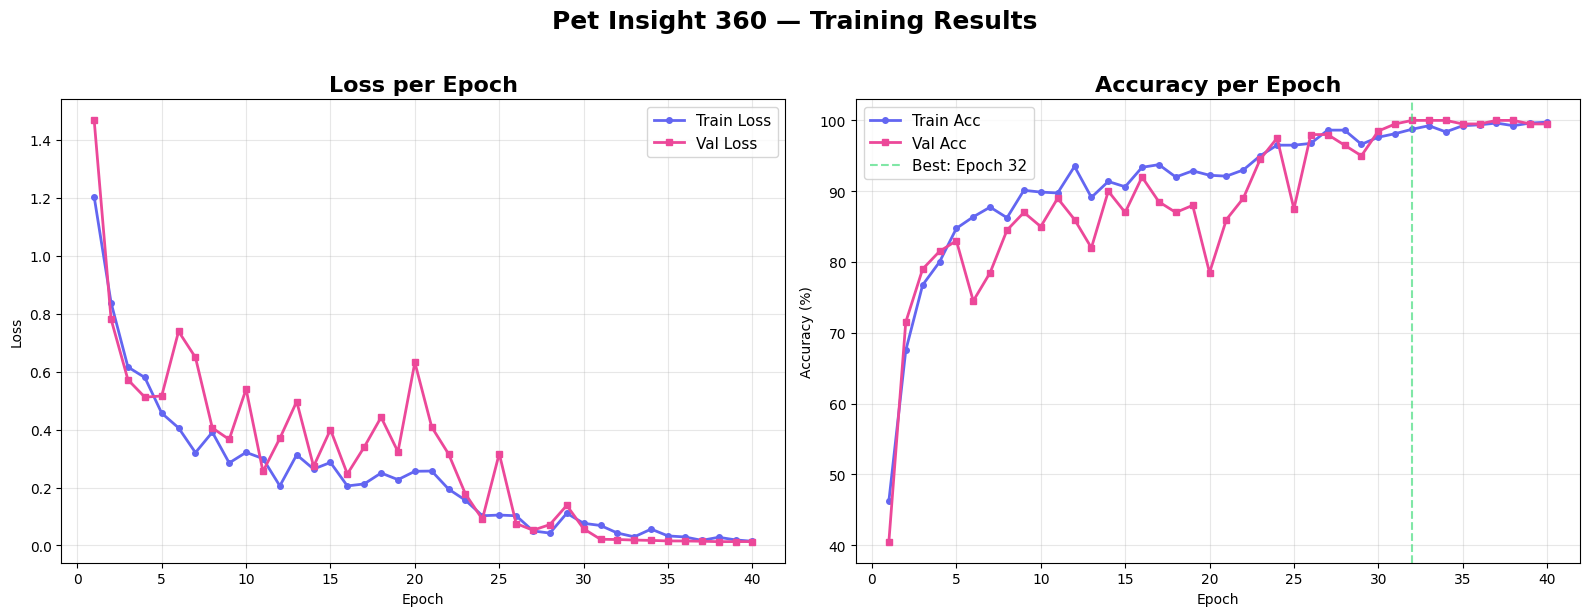

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#6366f1', linewidth=2, markersize=4)
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='#ec4899', linewidth=2, markersize=4)
ax1.set_title('Loss per Epoch', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', label='Train Acc', color='#6366f1', linewidth=2, markersize=4)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']], 's-', label='Val Acc', color='#ec4899', linewidth=2, markersize=4)
ax2.set_title('Accuracy per Epoch', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
best_epoch = np.argmax(history['val_acc'])
ax2.axvline(x=best_epoch+1, color='#4ade80', linestyle='--', alpha=0.7, label=f'Best: Epoch {best_epoch+1}')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)

plt.suptitle('Pet Insight 360 — Training Results', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── MLflow: log training curves ──
tracker.log_training_curves(fig)

## 🔍 Confusion Matrix & Classification Report

Evaluating: 100%|██████████| 7/7 [00:06<00:00,  1.15it/s]


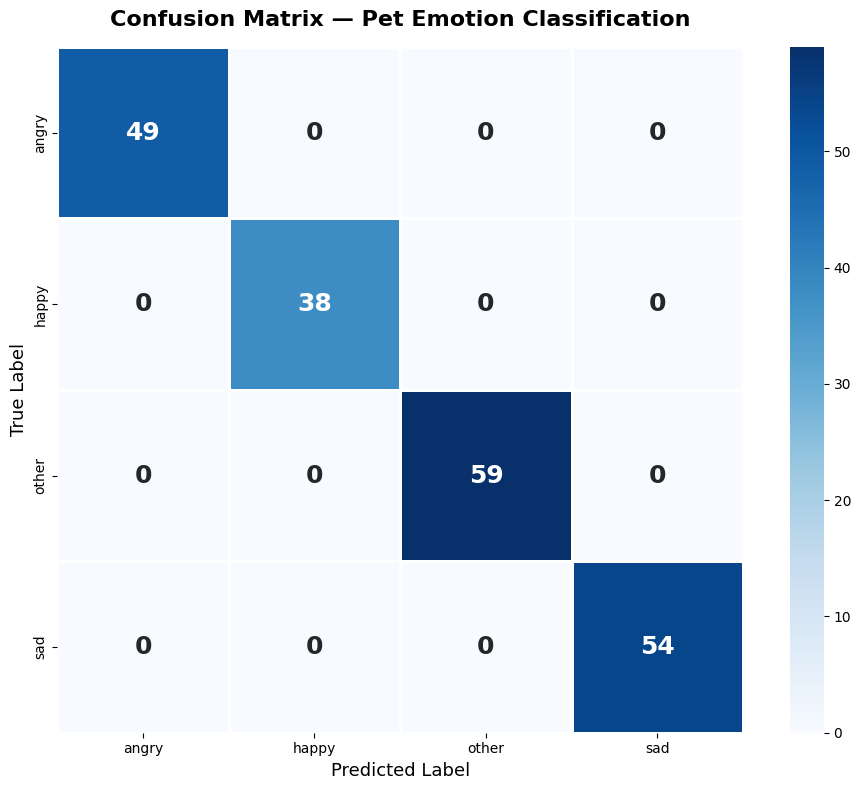


Classification Report:
              precision    recall  f1-score   support

       angry     1.0000    1.0000    1.0000        49
       happy     1.0000    1.0000    1.0000        38
       other     1.0000    1.0000    1.0000        59
         sad     1.0000    1.0000    1.0000        54

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

Per-Class Accuracy:
     angry: 100.00% (49 samples)
     happy: 100.00% (38 samples)
     other: 100.00% (59 samples)
       sad: 100.00% (54 samples)


In [15]:
model.load_state_dict(torch.load("pet_emotion.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

cm_fig = plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            square=True, linewidths=1, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'})
plt.title('Confusion Matrix — Pet Emotion Classification', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

report_str = classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, digits=4)
print("\nClassification Report:")
print(report_str)

per_class_acc = {}
print("Per-Class Accuracy:")
for i, name in enumerate(EMOTION_LABELS):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        acc = float((np.array(all_preds)[mask] == i).mean())
        per_class_acc[name] = acc
        print(f"  {name:>8s}: {acc:.2%} ({mask.sum()} samples)")

# ── MLflow: log evaluation ──
tracker.log_evaluation(
    confusion_matrix_fig=cm_fig,
    classification_report_str=report_str,
    per_class_acc=per_class_acc,
)

## 😻 Test Prediction on Sample Images

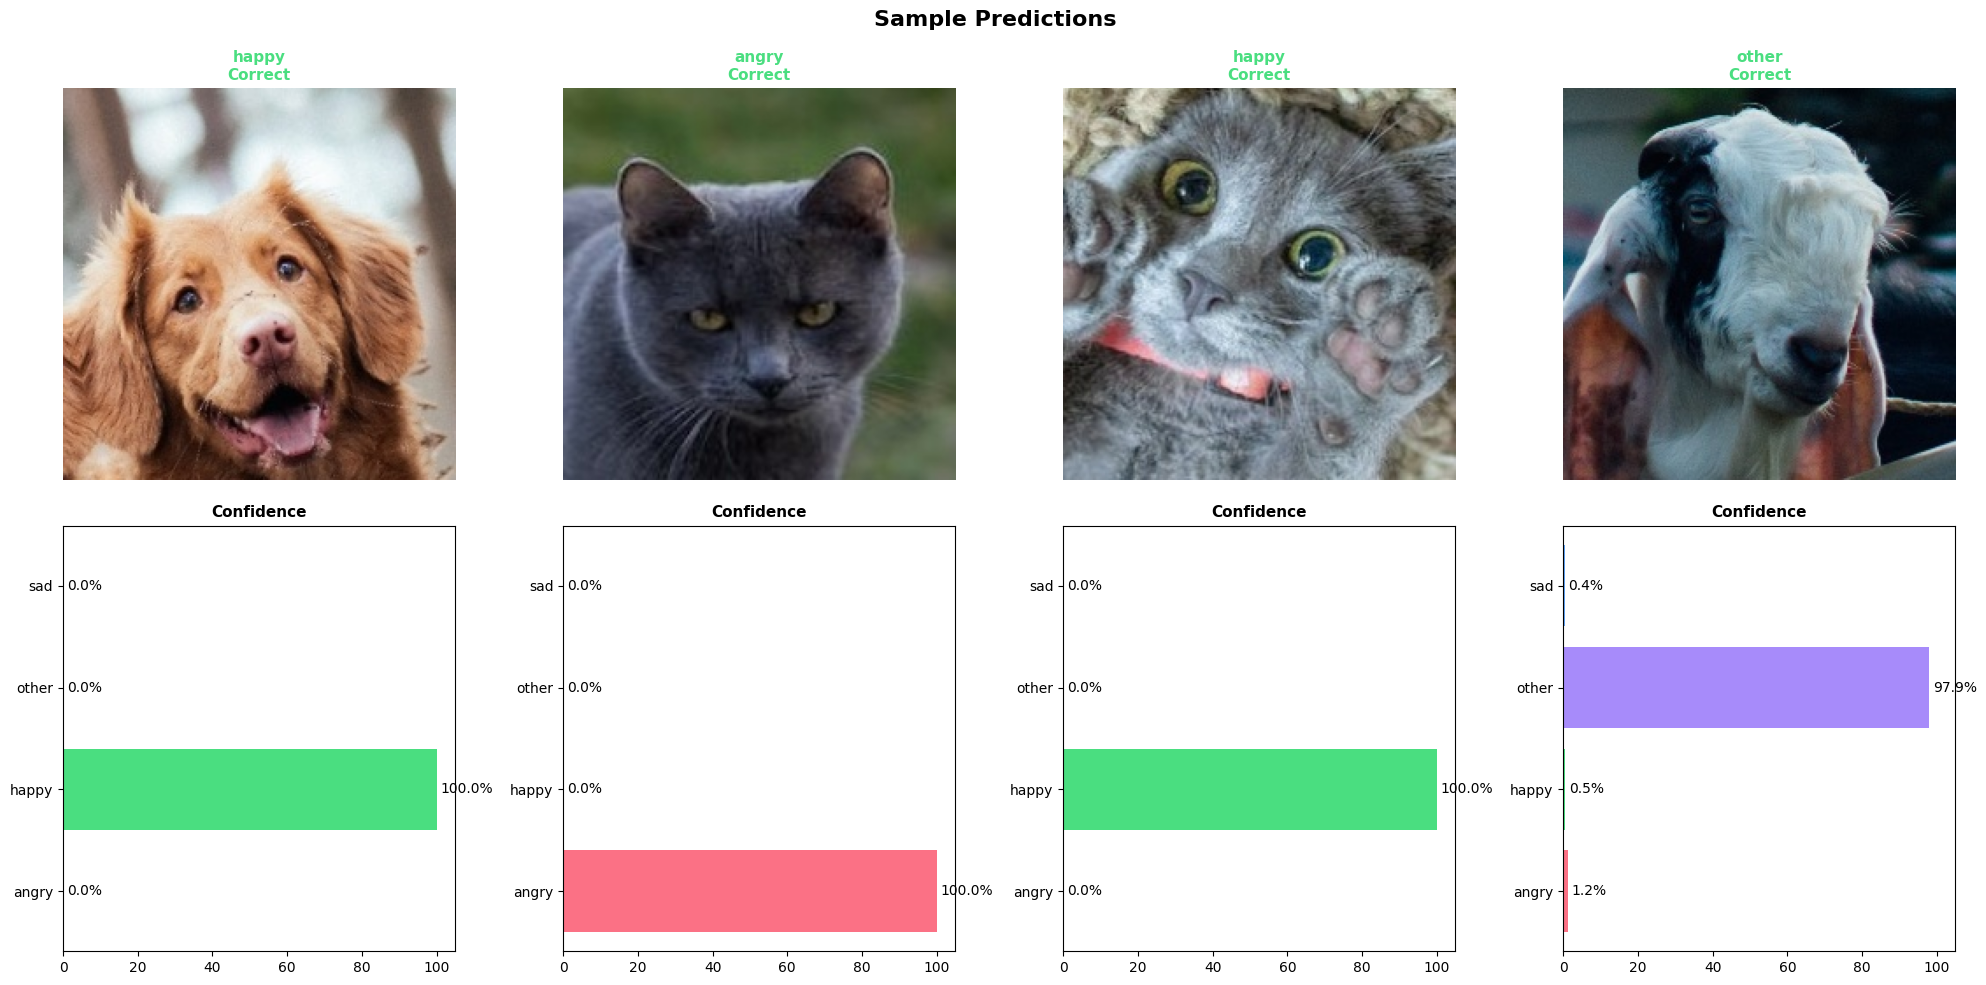

In [16]:
import random
n_samples = min(4, len(val_ds))
sample_indices = random.sample(range(len(val_ds)), n_samples)

fig_pred, axes = plt.subplots(2, n_samples, figsize=(5*n_samples, 10))
if n_samples == 1: axes = axes.reshape(2, 1)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
color_map = {'angry': '#fb7185', 'happy': '#4ade80', 'other': '#a78bfa', 'sad': '#60a5fa'}

for i, sidx in enumerate(sample_indices):
    img_tensor, true_label = val_ds[sidx]
    with torch.no_grad():
        probs = torch.softmax(model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
        pred_label = np.argmax(probs)
    img_np = np.clip(std * img_tensor.permute(1,2,0).numpy() + mean, 0, 1)
    true_name = EMOTION_LABELS[true_label]
    pred_name = EMOTION_LABELS[pred_label]
    is_correct = true_label == pred_label

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"{pred_name}\n{'Correct' if is_correct else 'Wrong (true: '+true_name+')'}",
                         fontsize=11, fontweight='bold', color='#4ade80' if is_correct else '#fb7185')
    axes[0, i].axis('off')

    colors = [color_map.get(e, '#94a3b8') for e in EMOTION_LABELS]
    bars = axes[1, i].barh(EMOTION_LABELS, probs*100, color=colors)
    axes[1, i].set_xlim(0, 105)
    axes[1, i].set_title('Confidence', fontsize=11, fontweight='bold')
    for bar, p in zip(bars, probs):
        axes[1, i].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'{p*100:.1f}%', va='center', fontsize=10)

plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── MLflow: log sample predictions ──
tracker.log_evaluation(
    confusion_matrix_fig=None,
    classification_report_str=None,
    sample_predictions_fig=fig_pred,
)

## 💾 Export Model

Copy `pet_emotion.pth` → `backend/weights/pet_emotion.pth`

In [18]:
size_mb = os.path.getsize('pet_emotion.pth') / (1024*1024)
print(f"File: pet_emotion.pth ({size_mb:.1f} MB)")
print(f"Classes: {EMOTION_LABELS}")
print(f"Best Val Acc: {best_val_acc:.2%}")
print(f"Epochs trained: {len(history['train_loss'])}")
print(f"\nCopy to: backend/weights/pet_emotion.pth")
print("Then run: cd backend && python -m uvicorn app:app --host 0.0.0.0 --port 8000")

# ── MLflow: End run & show summary ──
mlflow.log_metric("total_epochs", len(history['train_loss']))
mlflow.log_param("model_size_mb", round(size_mb, 1))
tracker.end_run()

print(f"\n{'='*50}")
print(f"MLflow Run ID: {run.info.run_id}")
print(f"MLflow Experiment: pet-emotion-training")
print(f"MLflow UI: mlflow server --host 0.0.0.0 --port 5000")
print(f"{'='*50}")

File: pet_emotion.pth (10.0 MB)
Classes: ['angry', 'happy', 'other', 'sad']
Best Val Acc: 100.00%
Epochs trained: 40

Copy to: backend/weights/pet_emotion.pth
Then run: cd backend && python -m uvicorn app:app --host 0.0.0.0 --port 8000
[MLflow] Run ended

MLflow Run ID: 6f5179b88afa41c78719360f02019268
MLflow Experiment: pet-emotion-training
MLflow UI: mlflow server --host 0.0.0.0 --port 5000
